# Cox explanations on the GPU: accuracy, tolerance and time

The purpose is to measure whether the new `CoxExplainer` makes high-dimensional survival explanations practical on the laptop GPU, and whether its chosen node counts achieve the requested accuracy.

We repeat GSE24080 (54,675 features) and TCGA LGG methylation (396,065 features), preserving their splits, all fitted features, four background patients, and three explained patients. CPU refits are verified **bit for bit** against the previous fits before using their saved float64 exact explanations as accuracy references. The full exact-node GPU rule is rerun for the first patient in each cohort, matching the previous experiment's scope.

The explanations add up to the difference between a patient's **relative hazard** and the mean relative hazard in the background. They do not explain survival probability directly, and they are associations under this background value function, not causal effects.

In [1]:
from pathlib import Path
import os, sys
ROOT = Path.cwd() if (Path.cwd() / "src/quadrashap").exists() else Path.cwd().parent
sys.path[:0] = [str(ROOT / "src"), str(ROOT)]
os.environ.setdefault("JAX_PLATFORMS", "METAL")
os.environ.setdefault("ENABLE_PJRT_COMPATIBILITY", "1")
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/quadrashap-mpl")
from IPython.display import display
import json
import numpy as np
import pandas as pd
from threadpoolctl import threadpool_limits
from benchmarks.cox_gpu_experiment import (
    OUTPUT, DATASETS, environment, write_json, launch_cpu_refit, load_experiment,
    small_exhaustive_benchmark, benchmark_sweep, benchmark_exact_gpu, summary_tables,
)
THREAD_LIMIT = threadpool_limits(limits=4)
ENV = environment(require_gpu=True)
write_json(OUTPUT / "environment.json", ENV)
print(json.dumps(ENV, indent=2))

Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!


Metal device set to: Apple M4 Pro
{
  "utc": "2026-09-13T10:56:16.425744+00:00",
  "platform": "macOS-26.6.2-arm64-arm-64bit",
  "python": "3.12.14",
  "executable": "/Users/siulunchau/Library/Mobile Documents/com~apple~CloudDocs/Documents/research_projects/current/QuadraSHAP/.venv-metal/bin/python",
  "devices": [
    "METAL:0"
  ],
  "backend": "METAL",
  "jit_disabled": false,
  "blas": [
    {
      "user_api": "blas",
      "internal_api": "openblas",
      "num_threads": 4,
      "prefix": "libopenblas",
      "filepath": "/Users/siulunchau/Library/Mobile Documents/com~apple~CloudDocs/Documents/research_projects/current/QuadraSHAP/.venv-metal/lib/python3.12/site-packages/numpy/.dylibs/libopenblas64_.0.dylib",
      "version": "0.3.23.dev",
      "threading_layer": "pthreads",
      "architecture": "armv8"
    }
  ],
  "packages": {
    "jax": "0.4.34",
    "jaxlib": "0.4.34",
    "numpy": "1.26.4",
    "scipy": "1.17.1",
    "pandas": "3.0.5",
    "scikit-survival": "0.26.0",
   

W0000 00:00:1789296976.373969  248695 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1789296976.423315  248695 service.cc:145] XLA service 0xb3c4a2600 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789296976.423333  248695 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1789296976.425401  248695 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1789296976.425409  248695 mps_client.cc:384] XLA backend will use up to 19069190144 bytes on device 0 for SimpleAllocator.


## Verify the model and device before benchmarking

Refitting retains all original features, using the existing sample-space ridge Cox fitter on CPU. This avoids a matrix with one row and column per feature. The collaborator's `CoxExplainer` accepts the resulting fitted Cox coefficients.

The CPU refit was executed as a separate recorded step using the same Python environment as the original run. Set `REFIT = True` to repeat it from this notebook. The comparison stops if coefficients or explanation inputs differ from the original run. GPU execution is required above; CPU fallback raises an error.

In [2]:
REFIT = False
FIT_ARTIFACTS = ("model_and_preprocessing.npz", "explanation_inputs.npz", "fit_summary.json", "refit_provenance.json")
if REFIT or not all((OUTPUT / name / filename).exists() for name in DATASETS for filename in FIT_ARTIFACTS):
    launch_cpu_refit()
experiments = {name: load_experiment(name) for name in DATASETS}
fit_table = pd.DataFrame([e["fit"] for e in experiments.values()])
display(fit_table[["dataset", "n_train", "n_test", "used_features", "train_events", "test_events",
                   "preprocessing_seconds", "fit_seconds", "test_c_index", "exact_nodes"]])

,dataset,n_train,n_test,used_features,train_events,test_events,preprocessing_seconds,fit_seconds,test_c_index,exact_nodes
0,gse24080,339,214,54675,125,43,1.065695,0.580145,0.657053,27338
1,tcga_lgg_methylation,383,128,396065,94,31,9.542622,1.137927,0.853791,198033


## A genuine exhaustive reference on a small model

Enumerating every possible feature coalition provides an independent correctness check. At 12 features there are 4,096 coalitions. This becomes impossible at genomic dimensions, so the large experiments use the algebraically exact quadrature rule instead.

A product-game Shapley integrand has degree at most `d - 1`; `ceil(d / 2)` Gauss–Legendre nodes integrate it exactly in real arithmetic. Floating-point rounding remains, even at that node count.

In [3]:
small = small_exhaustive_benchmark()
display(small)

,d,coalitions,m_q,backend,first_call_seconds,median_seconds,exhaustive_seconds,speedup_vs_exhaustive,relative_l2_error,max_absolute_error,top20_overlap
0,12,4096,6,prefix_scan_numpy,0.012406,0.000051,0.020426,399.534631,9.697448e-16,1.457168e-16,1.0
1,12,4096,6,prefix_scan_jax,0.150091,0.002417,0.020426,8.450037,9.060640e-08,2.264721e-08,1.0
2,12,4096,6,logspace_jax,0.020513,0.001462,0.020426,13.972208,6.585550e-08,1.147134e-08,1.0


## Requested tolerances and fixed-node runs

`eps` is an **absolute error tolerance for each feature**, used by the theoretical quadrature bound. It is not a relative tolerance, and the bound excludes floating-point rounding. Metal uses float32; CPU reference calculations use float64. We therefore report both maximum absolute error and relative L2 error (the length of the error vector divided by the length of the reference vector).

Each configuration has one first call and three timed repetitions. Timings include the full explanation API: factors, automatic node selection when requested, transfers, GPU execution and output synchronization. A first call includes compilation only if its shape is new. Pure GPU-kernel time is not claimed. Backends run sequentially to avoid competing for the GPU.

The first patient is compared with a verified saved float64 **exact** reference. The other two patients are compared with newly computed float64 **128-node approximations**; those comparisons do not establish exact error.

In [4]:
myeloma_sweep = benchmark_sweep(experiments["gse24080"])
display(myeloma_sweep.query("patient == 0 and mode == 'tolerance'"))

gse24080 logspace_jax: tolerance=0.1, 3 patients complete


gse24080 logspace_jax: tolerance=0.01, 3 patients complete


gse24080 logspace_jax: tolerance=0.001, 3 patients complete


gse24080 logspace_jax: tolerance=0.0001, 3 patients complete


gse24080 logspace_jax: fixed_nodes=1, 3 patients complete


...

gse24080 prefix_scan_numpy: fixed_nodes=16, 3 patients complete


gse24080 prefix_scan_numpy: fixed_nodes=32, 3 patients complete


gse24080 prefix_scan_numpy: fixed_nodes=64, 3 patients complete


gse24080 prefix_scan_numpy: fixed_nodes=128, 3 patients complete


,dataset,backend,device,mode,eps,m_q,patient,patient_id,first_call_seconds,median_seconds,...,bound,exact_nodes,reference,efficiency_residual,node_block,pair_block,relative_l2_error,max_absolute_error,top20_overlap,observed_tolerance_met
0,gse24080,logspace_jax,GPU,tolerance,0.1000,44,0,16574,0.041263,0.009148,...,0.024884,27338,"archived float64 exact, verified identical mod...",2.048907e-04,44,4,3.500232e-06,1.876246e-06,1.0,True
3,gse24080,logspace_jax,GPU,tolerance,0.0100,45,0,16574,0.029442,0.008730,...,0.002232,27338,"archived float64 exact, verified identical mod...",1.903637e-04,45,4,3.039619e-06,1.676178e-06,1.0,True
6,gse24080,logspace_jax,GPU,tolerance,0.0010,46,0,16574,0.032454,0.008332,...,0.000193,27338,"archived float64 exact, verified identical mod...",8.622313e-05,46,4,1.227892e-06,6.647329e-07,1.0,True
9,gse24080,logspace_jax,GPU,tolerance,0.0001,47,0,16574,0.033170,0.008353,...,0.000016,27338,"archived float64 exact, verified identical mod...",8.665173e-05,47,4,1.187337e-06,6.502683e-07,1.0,True
36,gse24080,prefix_scan_jax,GPU,tolerance,0.1000,44,0,16574,0.748155,0.028568,...,0.024884,27338,"archived float64 exact, verified identical mod...",1.786471e-03,44,4,3.963251e-05,2.068458e-05,1.0,True
39,gse24080,prefix_scan_jax,GPU,tolerance,0.0100,45,0,16574,0.065484,0.027583,...,0.002232,27338,"archived float64 exact, verified identical mod...",1.676944e-03,45,4,3.760849e-05,2.058074e-05,1.0,True
42,gse24080,prefix_scan_jax,GPU,tolerance,0.0010,46,0,16574,0.098077,0.028917,...,0.000193,27338,"archived float64 exact, verified identical mod...",1.840726e-03,46,4,4.094577e-05,2.139937e-05,1.0,True
45,gse24080,prefix_scan_jax,GPU,tolerance,0.0001,47,0,16574,0.084708,0.049179,...,0.000016,27338,"archived float64 exact, verified identical mod...",1.808822e-03,47,4,4.025134e-05,2.160892e-05,1.0,True
72,gse24080,prefix_scan_numpy,CPU,tolerance,0.1000,44,0,16574,0.066264,0.065024,...,0.024884,27338,"archived float64 exact, verified identical mod...",1.591616e-12,1,4,8.740987e-13,4.618528e-13,1.0,True
75,gse24080,prefix_scan_numpy,CPU,tolerance,0.0100,45,0,16574,0.066816,0.065900,...,0.002232,27338,"archived float64 exact, verified identical mod...",1.364242e-12,1,4,8.704839e-13,4.586331e-13,1.0,True


In [5]:
glioma_sweep = benchmark_sweep(experiments["tcga_lgg_methylation"])
display(glioma_sweep.query("patient == 0 and mode == 'tolerance'"))

tcga_lgg_methylation logspace_jax: tolerance=0.1, 3 patients complete


tcga_lgg_methylation logspace_jax: tolerance=0.01, 3 patients complete


tcga_lgg_methylation logspace_jax: tolerance=0.001, 3 patients complete


tcga_lgg_methylation logspace_jax: tolerance=0.0001, 3 patients complete


tcga_lgg_methylation logspace_jax: fixed_nodes=1, 3 patients complete


...

tcga_lgg_methylation prefix_scan_numpy: fixed_nodes=16, 3 patients complete


tcga_lgg_methylation prefix_scan_numpy: fixed_nodes=32, 3 patients complete


tcga_lgg_methylation prefix_scan_numpy: fixed_nodes=64, 3 patients complete


tcga_lgg_methylation prefix_scan_numpy: fixed_nodes=128, 3 patients complete


,dataset,backend,device,mode,eps,m_q,patient,patient_id,first_call_seconds,median_seconds,...,bound,exact_nodes,reference,efficiency_residual,node_block,pair_block,relative_l2_error,max_absolute_error,top20_overlap,observed_tolerance_met
0,tcga_lgg_methylation,logspace_jax,GPU,tolerance,0.1000,27,0,TCGA-CS-6665,0.100588,0.064023,...,0.089326,198033,"archived float64 exact, verified identical mod...",1.763294e-04,7,4,1.506425e-05,4.624197e-07,1.0,True
3,tcga_lgg_methylation,logspace_jax,GPU,tolerance,0.0100,28,0,TCGA-CS-6665,0.052246,0.061804,...,0.008213,198033,"archived float64 exact, verified identical mod...",2.093899e-04,7,4,1.767979e-05,5.527380e-07,1.0,True
6,tcga_lgg_methylation,logspace_jax,GPU,tolerance,0.0010,29,0,TCGA-CS-6665,0.070103,0.051669,...,0.000712,198033,"archived float64 exact, verified identical mod...",1.368518e-04,7,4,1.157010e-05,3.597150e-07,1.0,True
9,tcga_lgg_methylation,logspace_jax,GPU,tolerance,0.0001,30,0,TCGA-CS-6665,0.071284,0.064762,...,0.000058,198033,"archived float64 exact, verified identical mod...",1.467598e-04,7,4,1.303554e-05,3.997855e-07,1.0,True
36,tcga_lgg_methylation,prefix_scan_jax,GPU,tolerance,0.1000,27,0,TCGA-CS-6665,0.876993,0.132063,...,0.089326,198033,"archived float64 exact, verified identical mod...",2.633989e-02,9,4,2.189725e-03,6.984032e-05,1.0,True
39,tcga_lgg_methylation,prefix_scan_jax,GPU,tolerance,0.0100,28,0,TCGA-CS-6665,0.288048,0.225881,...,0.008213,198033,"archived float64 exact, verified identical mod...",2.637049e-02,9,4,2.192727e-03,6.995348e-05,1.0,True
42,tcga_lgg_methylation,prefix_scan_jax,GPU,tolerance,0.0010,29,0,TCGA-CS-6665,0.171220,0.165649,...,0.000712,198033,"archived float64 exact, verified identical mod...",2.630874e-02,9,4,2.187488e-03,6.976255e-05,1.0,True
45,tcga_lgg_methylation,prefix_scan_jax,GPU,tolerance,0.0001,30,0,TCGA-CS-6665,0.167028,0.180704,...,0.000058,198033,"archived float64 exact, verified identical mod...",2.632257e-02,9,4,2.189181e-03,6.983194e-05,1.0,True
72,tcga_lgg_methylation,prefix_scan_numpy,CPU,tolerance,0.1000,27,0,TCGA-CS-6665,0.321917,0.307222,...,0.089326,198033,"archived float64 exact, verified identical mod...",8.917311e-13,1,4,4.616562e-11,1.481745e-12,1.0,True
75,tcga_lgg_methylation,prefix_scan_numpy,CPU,tolerance,0.0100,28,0,TCGA-CS-6665,0.316363,0.316799,...,0.008213,198033,"archived float64 exact, verified identical mod...",9.077183e-13,1,4,4.616414e-11,1.481738e-12,1.0,True


## Full exact-node GPU reruns

Each run generates a fresh full rule on CPU, then evaluates every node using the parallel JAX log-space kernel on GPU. Node blocking limits working memory to a planned 512 MiB; partial sums are accumulated on the host in float64. The GPU arithmetic itself remains float32.

Rule construction and integration are timed separately, because CPU node generation can dominate the total. Exact-node runs are performed once per cohort, as before. Comparisons with the previous CPU exact runtime are explicitly historical: the CPU exact integrations are not rerun here.

In [6]:
myeloma_exact = benchmark_exact_gpu(experiments["gse24080"])
display(pd.DataFrame([myeloma_exact]).drop(columns="block_plan"))

gse24080: generating all 27,338 exact-rule nodes on CPU


gse24080: rule ready in 11.38s; starting full exact-node GPU integration


gse24080: exact GPU integration 1.204s; rule + integration 12.585s


,dataset,backend,patient,patient_id,d,m_q,repeats,rule_seconds,integration_seconds,total_compute_seconds,rule_moment_max_error,reference,qualification,efficiency_residual,relative_l2_error,max_absolute_error,top20_overlap,historical_cpu_integration_seconds,speedup_vs_historical_cpu_integration
0,gse24080,logspace_jax,0,16574,54675,27338,1,11.380929,1.203752,12.584681,5.572834e-13,"archived float64 exact, verified identical mod...",Exact polynomial degree; GPU float32 arithmeti...,0.000145,0.000002,0.000001,1.0,38.485284,31.971109


In [7]:
glioma_exact = benchmark_exact_gpu(experiments["tcga_lgg_methylation"])
display(pd.DataFrame([glioma_exact]).drop(columns="block_plan"))

tcga_lgg_methylation: generating all 198,033 exact-rule nodes on CPU


tcga_lgg_methylation: rule ready in 561.92s; starting full exact-node GPU integration


tcga_lgg_methylation: exact GPU integration 149.346s; rule + integration 711.270s


,dataset,backend,patient,patient_id,d,m_q,repeats,rule_seconds,integration_seconds,total_compute_seconds,rule_moment_max_error,reference,qualification,efficiency_residual,relative_l2_error,max_absolute_error,top20_overlap,historical_cpu_integration_seconds,speedup_vs_historical_cpu_integration
0,tcga_lgg_methylation,logspace_jax,0,TCGA-CS-6665,396065,198033,1,561.923277,149.346401,711.269678,1.034514e-11,"archived float64 exact, verified identical mod...",Exact polynomial degree; GPU float32 arithmeti...,0.000158,0.000014,4.196154e-07,1.0,2014.412844,13.488191


## Compare speed and achieved accuracy

The table below focuses on the first patient, where we have a verified float64 exact reference. A speedup above 1 means the approximate call was faster than its stated reference. The comparison with current CPU prefix-scan uses the same requested tolerance and includes node-selection overhead on both sides.

These are small-background, three-patient experiments on one laptop. They establish feasibility and local timings; they do not establish general CUDA performance or clinical usefulness.

In [8]:
summary = summary_tables()
cols = ["dataset", "backend", "eps", "m_q", "median_seconds", "median_budget_seconds",
        "max_absolute_error", "relative_l2_error", "observed_tolerance_met", "top20_overlap",
        "speedup_vs_cpu_prefix_same_tolerance", "speedup_vs_gpu_exact"]
display(summary[cols])

,dataset,backend,eps,m_q,median_seconds,median_budget_seconds,max_absolute_error,relative_l2_error,observed_tolerance_met,top20_overlap,speedup_vs_cpu_prefix_same_tolerance,speedup_vs_gpu_exact
0,gse24080,logspace_jax,0.1000,44,0.009148,0.003344,1.876246e-06,3.500232e-06,True,1.0,7.107664,131.579761
1,gse24080,logspace_jax,0.0100,45,0.008730,0.003274,1.676178e-06,3.039619e-06,True,1.0,7.548487,137.882206
2,gse24080,logspace_jax,0.0010,46,0.008332,0.003326,6.647329e-07,1.227892e-06,True,1.0,7.991608,144.480559
3,gse24080,logspace_jax,0.0001,47,0.008353,0.003316,6.502683e-07,1.187337e-06,True,1.0,8.226709,144.109406
4,gse24080,prefix_scan_jax,0.1000,44,0.028568,0.003730,2.068458e-05,3.963251e-05,True,1.0,2.276139,42.136742
5,gse24080,prefix_scan_jax,0.0100,45,0.027583,0.003328,2.058074e-05,3.760849e-05,True,1.0,2.389182,43.641278
6,gse24080,prefix_scan_jax,0.0010,46,0.028917,0.003710,2.139937e-05,4.094577e-05,True,1.0,2.302557,41.628008
7,gse24080,prefix_scan_jax,0.0001,47,0.049179,0.009384,2.160892e-05,4.025134e-05,True,1.0,1.397308,24.477012
8,gse24080,prefix_scan_numpy,0.1000,44,0.065024,0.003337,4.618528e-13,8.740987e-13,True,1.0,1.000000,18.512377
9,gse24080,prefix_scan_numpy,0.0100,45,0.065900,0.003284,4.586331e-13,8.704839e-13,True,1.0,1.000000,18.266203


Matplotlib is building the font cache; this may take a moment.


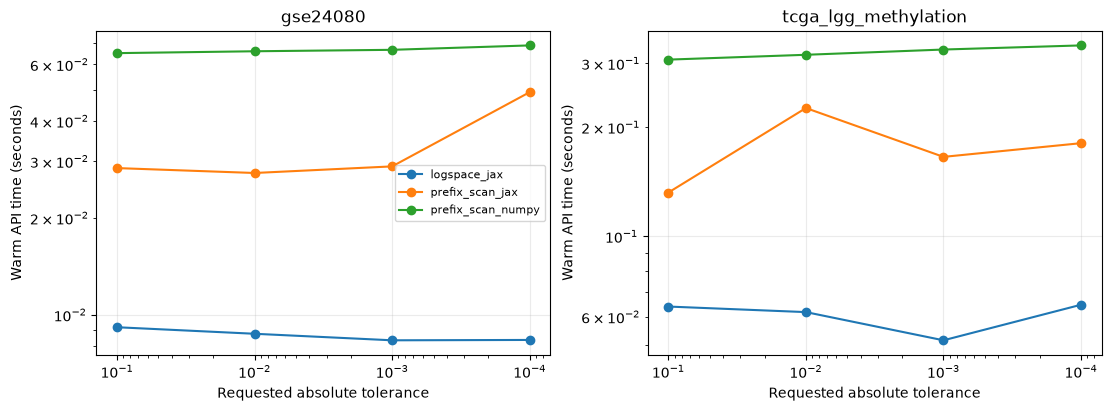

In [9]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, name in zip(axes, DATASETS):
    for backend, g in summary[summary.dataset.eq(name)].groupby("backend", sort=False):
        ax.plot(g.eps, g.median_seconds, "o-", label=backend)
    ax.set(xscale="log", yscale="log", xlabel="Requested absolute tolerance", ylabel="Warm API time (seconds)", title=name)
    ax.invert_xaxis()
    ax.grid(alpha=.25)
axes[0].legend(fontsize=8)
fig.savefig(OUTPUT / "tolerance_runtime.png", dpi=180)
fig.savefig(OUTPUT / "tolerance_runtime.svg")
plt.show()

## Recorded outcome

JAX-Metal ran the attribution kernels on the Apple M4 Pro GPU with JIT enabled. The repaired log-space backend met all eight first-patient tolerance comparisons against verified float64 exact references. Across those cases, warm API time was 8.3–9.1 ms for GSE24080 and 51.7–64.8 ms for methylation, 4.8–8.2 times faster than the current CPU prefix-scan path at the same tolerance.

Full exact-node GPU integration took 1.204 s and 149.346 s respectively. Fresh CPU rule generation added 11.381 s and 561.923 s. The complete notebook ran in 863.817 s (14 min 24 s), following the separately recorded CPU refits.

The original GPU prefix-scan path missed the 1e-4 target for one methylation patient against the float64 128-node reference. That comparison and the float32 rounding limitation are retained in the results.

See the [complete report](../benchmarks/results/cox_gpu_tolerance/README.md) and [comparison CSV](../benchmarks/results/cox_gpu_tolerance/tolerance_summary.csv) for definitions, precision qualifications, historical CPU exact timings, and all results.